<a href="https://colab.research.google.com/github/paramak23/TautomerAnalyzer/blob/main/Tautomers_handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tautomers Handling

##Installing RDKit

In [8]:
!pip install rdkit

##Implementation of required RDKit packages

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display
import pandas as pd

##Tautomers Handling & Standardization

###Tautomer Generation: 2-pyridinone

Tautomers for N1C(C=CC=C1)=O: ['O=c1cccc[nH]1', 'Oc1ccccn1']


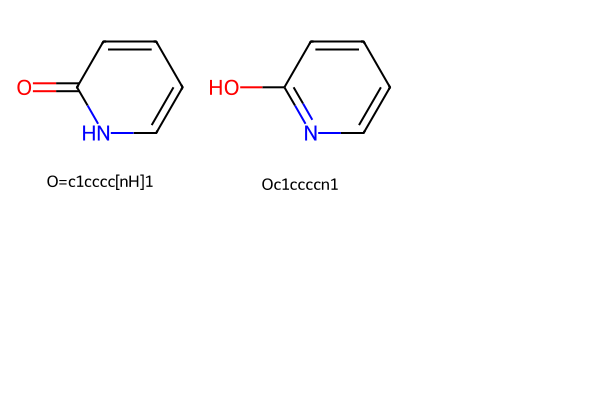

In [10]:
raw_SMILES = 'N1C(C=CC=C1)=O' #2-Pyridone
raw_mol = Chem.MolFromSmiles(raw_SMILES)

enumerator = rdMolStandardize.TautomerEnumerator()
tautomers = enumerator.Enumerate(raw_mol)
tautomers_smi = [Chem.MolToSmiles(t, canonical=True) for t in tautomers]

if tautomers_smi:
  print(f'Tautomers for {raw_SMILES}: {tautomers_smi}')
else:
  print(f'No tautomers found for {raw_SMILES}')

drawer = rdMolDraw2D.MolDraw2DSVG(600, 400, 200, 200)
drawer.DrawMolecules(tautomers, legends=[Chem.MolToSmiles(t, canonical=True) for t in tautomers])
drawer.FinishDrawing()
svg_text = drawer.GetDrawingText()
display(SVG(svg_text))

#Simple canonicalization of SMILES not identified the tautomers
## tested with 2-pyridone and 2-hydroxypyridine

In [11]:
smi_1 = 'N1C(C=CC=C1)=O'
smi_2 = 'OC1=NC=CC=C1'

mol_smi_1 = Chem.MolFromSmiles(smi_1)
mol_smi_2 = Chem.MolFromSmiles(smi_2)

can_smi_1 = Chem.MolToSmiles(mol_smi_1, canonical=True)
can_smi_2 = Chem.MolToSmiles(mol_smi_2, canonical=True)

if can_smi_1 == can_smi_2:
  print(f'Tautomers identified')
else:
    print(f'Standard canonicalization failed to identify tautomers')

print(can_smi_1)
print(can_smi_2)

Standard canonicalization failed to identify tautomers
O=c1cccc[nH]1
Oc1ccccn1


###Checking the two Raw SMILES are Tautomers or not

In [16]:
def FindingTautomers(smi_1, smi_2):

  # Converting RDKit object for raw SMILES
  mol_1 = Chem.MolFromSmiles(smi_1)
  mol_2 = Chem.MolFromSmiles(smi_2)

  # Creating Tautomers of each SMILES
  enumerator = rdMolStandardize.TautomerEnumerator()
  tautomers_1 = enumerator.Enumerate(mol_1)
  tautomers_2 = enumerator.Enumerate(mol_2)

  # print(type(tautomers_1))

  can_smil_1 = [Chem.MolToSmiles(t, canonical=True) for t in tautomers_1]
  can_smil_2 = [Chem.MolToSmiles(t, canonical=True) for t in tautomers_2]

  # print(can_smil_1)
  # print(can_smil_2)

  # Compare canonical tautomeric SMILES for true equivalence
  if can_smil_1 == can_smil_2:
    print(f'"{smi_1}" and "{smi_2}" are tautomers')
  else:
    print(f'"{smi_1}" and "{smi_2}" are not tautomers')

smi_1 = 'N1C(C=CC=C1)=O'
smi_2 = 'OC1=NC=CC=C1'

FindingTautomers(smi_1, smi_2)

"N1C(C=CC=C1)=O" and "OC1=NC=CC=C1" are tautomers


###Used cases

###1. Generate a sample dataset
###2. Analyse each Raw SMILES
###3. Removing redundancies
###4. Finding the Tautomer possibilities
###5. Generating Tautomer Dataset

In [13]:
def GenerateDataset(df):
    # Convert SMILES to RDKit objects
    mols_obj = df['Raw_SMILES'].apply(Chem.MolFromSmiles)

    # Initialize the Tautomer tools
    enumerator = rdMolStandardize.TautomerEnumerator()

    # 1. Generate all tautomers for each molecule
    tautomer_lists = mols_obj.apply(lambda x: enumerator.Enumerate(x))

    # 2. Get the SINGLE "Canonical Tautomer" (The standardized form)
    df['Standardized_SMILES'] = mols_obj.apply(lambda x: Chem.MolToSmiles(enumerator.Canonicalize(x)))

    # 3. Removal of redundancy in the dataset
    # 3.1. Explicitly create a copy to avoid SettingWithCopyWarning
    cleaned_df = df.drop_duplicates(subset=['Standardized_SMILES']).copy()

    # 4. Handle the list of all possible forms
    cleaned_df['Tautomers_SMILES'] = tautomer_lists.apply(lambda x: [Chem.MolToSmiles(t) for t in x])

    # 5. Metadata
    cleaned_df['Has_tautomers'] = tautomer_lists.apply(lambda x: 'Yes' if len(x) > 1 else 'No')
    cleaned_df['Tautomers_count'] = tautomer_lists.apply(len) # Standard: 1 means only itself exists

    return cleaned_df

compounds_data = [
    {'Compound_Name': '2-Hydroxypyridine', 'Raw_SMILES': 'OC1=NC=CC=C1'},
    {'Compound_Name': '2-Chloropyridine', 'Raw_SMILES': 'ClC1=NC=CC=C1'},
    {'Compound_Name': '2-Phenylimidazole', 'Raw_SMILES': 'C1(=CC=CC=C1)C=1NC=CN1'},
    {'Compound_Name': '2-Pyridone', 'Raw_SMILES': 'N1C(C=CC=C1)=O'},
    {'Compound_Name': '4-Hydroxyquinoline', 'Raw_SMILES': 'OC1=CC=NC2=CC=CC=C12' },
    {'Compound_Name': '2-piperidinone' , 'Raw_SMILES': 'N1C(CCCC1)=O'},
    {'Compound_Name': 'Benzothiazole', 'Raw_SMILES': 'S1C=NC2=C1C=CC=C2'},
    {'Compound_Name': 'cyclohexanone', 'Raw_SMILES': 'C1(CCCCC1)=O'},
    {'Compound_Name': 'dimethylmalonate', 'Raw_SMILES': 'C(CC(=O)OC)(=O)OC'},
    {'Compound_Name': 'Morpholine', 'Raw_SMILES': 'N1CCOCC1'},
    {'Compound_Name': 'Acetone', 'Raw_SMILES': 'CC(=O)C'}

]

# To show the result nicely in Colab:
df_final = GenerateDataset(pd.DataFrame(compounds_data))
display(df_final)

,Compound_Name,Raw_SMILES,Standardized_SMILES,Tautomers_SMILES,Has_tautomers,Tautomers_count
0,2-Hydroxypyridine,OC1=NC=CC=C1,O=c1cccc[nH]1,"[O=c1cccc[nH]1, Oc1ccccn1]",Yes,2
1,2-Chloropyridine,ClC1=NC=CC=C1,Clc1ccccn1,[Clc1ccccn1],No,1
2,2-Phenylimidazole,C1(=CC=CC=C1)C=1NC=CN1,c1ccc(-c2ncc[nH]2)cc1,[c1ccc(-c2ncc[nH]2)cc1],No,1
4,4-Hydroxyquinoline,OC1=CC=NC2=CC=CC=C12,O=c1cc[nH]c2ccccc12,"[O=C1CC=Nc2ccccc21, O=c1cc[nH]c2ccccc12, Oc1cc...",Yes,3
5,2-piperidinone,N1C(CCCC1)=O,O=C1CCCCN1,"[O=C1CCCCN1, OC1=CCCCN1, OC1=NCCCC1]",Yes,3
6,Benzothiazole,S1C=NC2=C1C=CC=C2,c1ccc2scnc2c1,[c1ccc2scnc2c1],No,1
7,cyclohexanone,C1(CCCCC1)=O,O=C1CCCCC1,"[O=C1CCCCC1, OC1=CCCCC1]",Yes,2
8,dimethylmalonate,C(CC(=O)OC)(=O)OC,COC(=O)CC(=O)OC,"[COC(=O)C=C(O)OC, COC(=O)CC(=O)OC]",Yes,2
9,Morpholine,N1CCOCC1,C1COCCN1,[C1COCCN1],No,1
10,Acetone,CC(=O)C,CC(C)=O,"[C=C(C)O, CC(C)=O]",Yes,2
